In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("/content/placement.csv")

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [5]:
df.shape

(100, 4)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


### preprocessing


In [7]:
# removing the unwanted column
df = df.iloc[:,1:]

In [8]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


## EDA

In [9]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'IQ_of students')

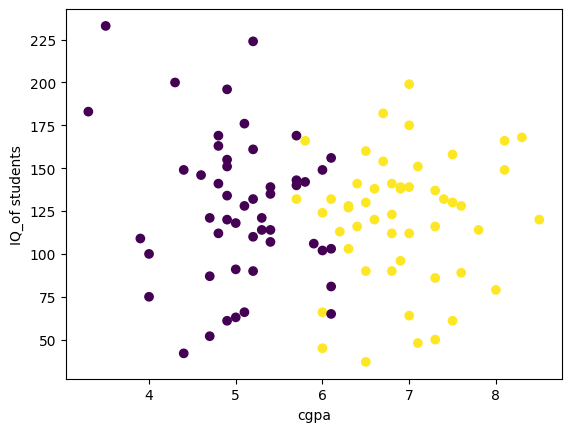

In [16]:
plt.scatter(df['cgpa'],df['iq'], c=df['placement'])
plt.xlabel("cgpa")
plt.ylabel("IQ_of students")

### Feature engineering | **not needed for this dataset**

## Extract input and output columns

In [17]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [18]:
X.shape

(100, 2)

In [19]:
y.shape

(100,)

## Train Test Split

In [22]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.1)

In [25]:
X_train

,cgpa,iq
99,6.2,113.0
89,4.9,151.0
33,6.0,149.0
59,4.8,112.0
52,7.0,175.0
...,...,...
62,6.0,102.0
37,8.1,149.0
16,5.2,224.0
70,6.3,127.0


In [26]:
y_test

,placement
66,1
86,0
56,0
20,1
30,1
21,1
18,0
88,0
80,0
2,0


## scaling

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
X_train

array([[ 0.16578917, -0.2572167 ],
       [-0.98198199,  0.68462604],
       [-0.01079101,  0.63505537],
       [-1.07027208, -0.28200204],
       [ 0.87210988,  1.27947409],
       [ 0.07749908,  0.21370467],
       [ 0.78381979,  0.36241668],
       [ 1.31356033,  0.85812339],
       [-1.7765928 , -1.19905945],
       [-0.27566128,  0.21370467],
       [-0.80540181, -1.42212747],
       [ 0.60723961,  0.75898205],
       [ 1.31356033,  0.164134  ],
       [-0.01079101, -1.94261951],
       [-2.39462342,  1.47775678],
       [ 0.87210988,  1.87432214],
       [-0.27566128,  0.48634336],
       [-0.54053155, -0.40592872],
       [ 0.34236935,  0.43677269],
       [-0.98198199,  0.78376738],
       [-0.8936919 , -1.49648347],
       [ 0.43065944, -0.82727942],
       [ 1.84330087,  1.05640607],
       [-0.8936919 , -0.13329003],
       [-0.0990811 , -0.43071405],
       [ 2.01988104,  1.10597675],
       [ 0.60723961,  1.45297144],
       [-1.86488289, -0.35635804],
       [ 0.07749908,

## Train The model

In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

## Evaluate the model

In [31]:
y_pred = model.predict(X_test)

In [32]:
y_test

,placement
66,1
86,0
56,0
20,1
30,1
21,1
18,0
88,0
80,0
2,0


In [33]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.9

## Seeing the decision boundry

<Axes: >

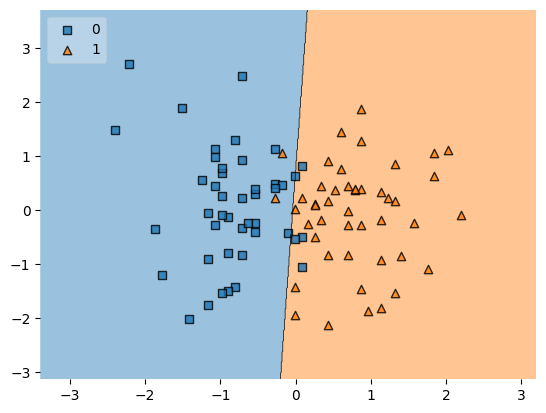

In [35]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X_train,y_train.values,clf=model, legend =2)

## Deploy the model